In [1]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

In [2]:
# Load datasets
train_data = pd.read_csv('train_data.csv')
val_data = pd.read_csv('validation_data.csv')
test_data = pd.read_csv('test_data.csv')

# Separate features and target
X_train = train_data.drop('Burnout Score', axis=1)
y_train = train_data['Burnout Score']

X_val = val_data.drop('Burnout Score', axis=1)
y_val = val_data['Burnout Score']

X_test = test_data.drop('Burnout Score', axis=1)
y_test = test_data['Burnout Score']

In [3]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Build a Multi-Layer Perceptron (10 marks)
Architecture:
1. Input Layer: 4 neurons (one for each feature)
2. Hidden Layer 1: 64 neurons
3. Hidden Layer 2: 32 neurons
4. Output Layer: 1 neuron (predicts the burnout score)
Use Mean Squared Error (MSE) as the loss function for training the model

In [4]:
class BurnoutDataset(Dataset):
    def __init__(self, features, targets):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets.values, dtype=torch.float32).view(-1, 1)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [5]:
# Create datasets
train_dataset = BurnoutDataset(X_train_scaled, y_train)
val_dataset = BurnoutDataset(X_val_scaled, y_val)
test_dataset = BurnoutDataset(X_test_scaled, y_test)

# Create dataloaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [6]:
class MLP(nn.Module):
    def __init__(self, activation_fn):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(4, 64),
            activation_fn,
            nn.Linear(64, 32),
            activation_fn,
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.model(x)

Experiment with two different Activation functions for hidden layers:
1. Sigmoid
2. ReLU (Rectified Linear Unit)
Train the neural network with Stochastic Gradient Descent (SGD) and Learning Rate
η=0.001 (You are advised to use the builtin functions from the libraries such as
loss.backward() from PyTorch to realize the backpropagation. You may refer to this help
notebook.)

In [7]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50):
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for features, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * features.size(0)
        
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)
        
        # Validation phase
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for features, targets in val_loader:
                outputs = model(features)
                loss = criterion(outputs, targets)
                running_val_loss += loss.item() * features.size(0)
        
        val_epoch_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(val_epoch_loss)
        
        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {epoch_loss:.4f}, Validation Loss: {val_epoch_loss:.4f}")
        
    return train_losses, val_losses

In [8]:
# Define the model with Sigmoid activation
activation_fn = nn.Sigmoid()
model_sigmoid = MLP(activation_fn)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model_sigmoid.parameters(), lr=0.001)

In [9]:
print("Training with Sigmoid Activation Function")
train_losses_sigmoid, val_losses_sigmoid = train_model(
    model_sigmoid, train_loader, val_loader, criterion, optimizer, epochs=50)

Training with Sigmoid Activation Function
Epoch 1/50, Training Loss: 0.4186, Validation Loss: 0.1505
Epoch 2/50, Training Loss: 0.0893, Validation Loss: 0.0573
Epoch 3/50, Training Loss: 0.0505, Validation Loss: 0.0462
Epoch 4/50, Training Loss: 0.0459, Validation Loss: 0.0449
Epoch 5/50, Training Loss: 0.0454, Validation Loss: 0.0446
Epoch 6/50, Training Loss: 0.0452, Validation Loss: 0.0445
Epoch 7/50, Training Loss: 0.0451, Validation Loss: 0.0444
Epoch 8/50, Training Loss: 0.0450, Validation Loss: 0.0443
Epoch 9/50, Training Loss: 0.0449, Validation Loss: 0.0442
Epoch 10/50, Training Loss: 0.0448, Validation Loss: 0.0442
Epoch 11/50, Training Loss: 0.0447, Validation Loss: 0.0441
Epoch 12/50, Training Loss: 0.0447, Validation Loss: 0.0440
Epoch 13/50, Training Loss: 0.0445, Validation Loss: 0.0439
Epoch 14/50, Training Loss: 0.0445, Validation Loss: 0.0438
Epoch 15/50, Training Loss: 0.0444, Validation Loss: 0.0437
Epoch 16/50, Training Loss: 0.0443, Validation Loss: 0.0436
Epoch 1

In [10]:
# Define the model with ReLU activation
activation_fn = nn.ReLU()
model_relu = MLP(activation_fn)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model_relu.parameters(), lr=0.001)

In [11]:
print("\nTraining with ReLU Activation Function")
train_losses_relu, val_losses_relu = train_model(
    model_relu, train_loader, val_loader, criterion, optimizer, epochs=50)


Training with ReLU Activation Function
Epoch 1/50, Training Loss: 0.1322, Validation Loss: 0.1095
Epoch 2/50, Training Loss: 0.1022, Validation Loss: 0.0875
Epoch 3/50, Training Loss: 0.0835, Validation Loss: 0.0732
Epoch 4/50, Training Loss: 0.0709, Validation Loss: 0.0632
Epoch 5/50, Training Loss: 0.0617, Validation Loss: 0.0556
Epoch 6/50, Training Loss: 0.0547, Validation Loss: 0.0496
Epoch 7/50, Training Loss: 0.0489, Validation Loss: 0.0445
Epoch 8/50, Training Loss: 0.0440, Validation Loss: 0.0402
Epoch 9/50, Training Loss: 0.0398, Validation Loss: 0.0363
Epoch 10/50, Training Loss: 0.0360, Validation Loss: 0.0329
Epoch 11/50, Training Loss: 0.0326, Validation Loss: 0.0299
Epoch 12/50, Training Loss: 0.0296, Validation Loss: 0.0271
Epoch 13/50, Training Loss: 0.0269, Validation Loss: 0.0246
Epoch 14/50, Training Loss: 0.0245, Validation Loss: 0.0224
Epoch 15/50, Training Loss: 0.0223, Validation Loss: 0.0203
Epoch 16/50, Training Loss: 0.0203, Validation Loss: 0.0185
Epoch 17/

In [12]:
def evaluate_model(model, test_loader, criterion):
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for features, targets in test_loader:
            outputs = model(features)
            loss = criterion(outputs, targets)
            running_test_loss += loss.item() * features.size(0)
    test_loss = running_test_loss / len(test_loader.dataset)
    return test_loss

In [13]:
#sigmoid
test_loss_sigmoid = evaluate_model(model_sigmoid, test_loader, criterion)
print(f"\nTest Loss with Sigmoid Activation: {test_loss_sigmoid:.4f}")


Test Loss with Sigmoid Activation: 0.0385


In [14]:
#relu
test_loss_relu = evaluate_model(model_relu, test_loader, criterion)
print(f"Test Loss with ReLU Activation: {test_loss_relu:.4f}")

Test Loss with ReLU Activation: 0.0021


Part 3: Train the Model and Track Metrics (15 marks)
Train the model for 20-30 epochs and track the following metrics:
1. Training Loss vs. Epochs
2. Validation Loss vs. Epochs
3. Test Loss (Bar Plot)

In [15]:
num_epochs = 30
train_losses = []
val_losses = []
test_losses = []
model = model_relu
for epoch in range(num_epochs):
    # Training Phase
    model.train()
    running_train_loss = 0.0
    for features, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * features.size(0)
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # Validation Phase
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for features, targets in val_loader:
            outputs = model(features)
            loss = criterion(outputs, targets)
            running_val_loss += loss.item() * features.size(0)
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # test loss for tracking metrics
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for features, targets in test_loader:
            outputs = model(features)
            loss = criterion(outputs, targets)
            running_test_loss += loss.item() * features.size(0)
    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {epoch_train_loss:.4f}, Validation Loss: {epoch_val_loss:.4f}, Test Loss: {epoch_test_loss:.4f}")

Epoch 1/30, Training Loss: 0.0024, Validation Loss: 0.0025, Test Loss: 0.0021
Epoch 2/30, Training Loss: 0.0023, Validation Loss: 0.0025, Test Loss: 0.0020
Epoch 3/30, Training Loss: 0.0023, Validation Loss: 0.0024, Test Loss: 0.0020
Epoch 4/30, Training Loss: 0.0023, Validation Loss: 0.0024, Test Loss: 0.0019
Epoch 5/30, Training Loss: 0.0022, Validation Loss: 0.0024, Test Loss: 0.0019
Epoch 6/30, Training Loss: 0.0022, Validation Loss: 0.0023, Test Loss: 0.0019
Epoch 7/30, Training Loss: 0.0021, Validation Loss: 0.0023, Test Loss: 0.0018
Epoch 8/30, Training Loss: 0.0021, Validation Loss: 0.0023, Test Loss: 0.0018
Epoch 9/30, Training Loss: 0.0021, Validation Loss: 0.0022, Test Loss: 0.0018
Epoch 10/30, Training Loss: 0.0020, Validation Loss: 0.0022, Test Loss: 0.0018
Epoch 11/30, Training Loss: 0.0020, Validation Loss: 0.0022, Test Loss: 0.0017
Epoch 12/30, Training Loss: 0.0020, Validation Loss: 0.0021, Test Loss: 0.0017
Epoch 13/30, Training Loss: 0.0020, Validation Loss: 0.0021, 

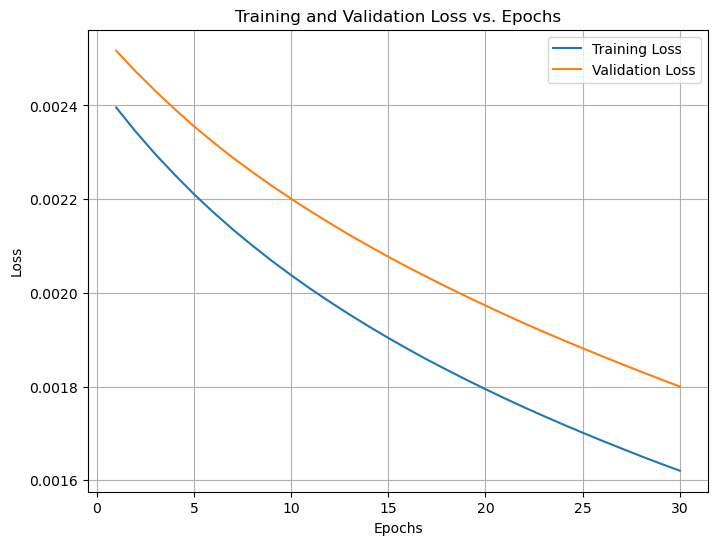

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Evaluate on Test Set
model.eval()
running_test_loss = 0.0
with torch.no_grad():
    for features, targets in test_loader:
        outputs = model(features)
        loss = criterion(outputs, targets)
        running_test_loss += loss.item() * features.size(0)
test_loss = running_test_loss / len(test_loader.dataset)
print(f"\nTest Loss: {test_loss:.4f}")


Test Loss: 0.0014


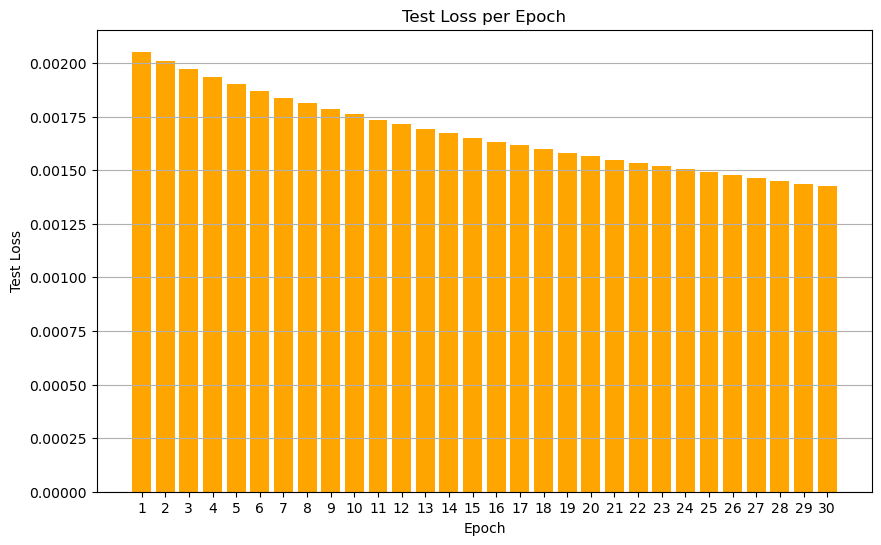

In [18]:
# Plot Test Losses as a Bar Plot
plt.figure(figsize=(10,6))
plt.bar(range(1, num_epochs+1), test_losses, color='orange')
plt.xlabel('Epoch')
plt.ylabel('Test Loss')
plt.title('Test Loss per Epoch')
plt.xticks(range(1, num_epochs+1))
plt.grid(axis='y')
plt.show()

In [19]:
print(epoch_train_loss)
print(epoch_val_loss)
print(test_loss)

0.0016203914802255376
0.0018000601974005501
0.0014246648540720344


Part 4: Results and conclusions (10 marks)
Provide a comparison table summarizing the results. It should have the following
information:
Activation Function, Final training loss, Final validation loss, Test loss.
Analyze the results and provide conclusions in points in a markdown block at the end of
Jupiter notebook

In [20]:

final_loss_metrics = {
    "Activation Function":["Sigmoid","Relu"],
    "Final_Train_Loss":[train_losses_sigmoid[-1],train_losses_relu[-1]],
    "Final_Val_Loss":[val_losses_sigmoid[-1],val_losses_relu[-1]],
    "Final_Test_Loss":[test_loss_sigmoid,test_loss_relu]
}

final_table = pd.DataFrame(final_loss_metrics)

In [21]:
final_table

,Activation Function,Final_Train_Loss,Final_Val_Loss,Final_Test_Loss
0,Sigmoid,0.041157,0.040509,0.038549
1,Relu,0.002451,0.002565,0.002099


#### CONCLUSIONS
- Effectiveness of ReLU Activation Function: 

    * The ReLU activation function led to faster convergence and better performance. 

    * It mitigated the vanishing gradient problem, enabling the network to learn more complex patterns. 

    * ReLU is more effective for deep neural networks and regression tasks. 

- Limitations of Sigmoid Activation Function: 

    * The Sigmoid activation function caused slower learning and higher losses. 

    * Susceptible to vanishing gradients, especially in deeper networks. 

    * Less suitable for this task and architecture. 

- Importance of Activation Function Selection: 

    * Activation functions play a crucial role in neural network performance. 

    * Proper selection can significantly improve training efficiency and model accuracy. 

    * ReLU should be preferred over Sigmoid for similar regression problems. 